# Superstore Rolling Sales Forecast

## Business Problem
Project 1 identified a clear seasonal pattern in Superstore's sales, with October consistently underperforming and Q4 (Nov-Dec) driving the year's strongest revenue. This project turns that pattern into a working 6-month rolling forecast, combining the company's overall growth trend with its seasonal cycle, to answer: what should management expect for sales over the next two quarters, under base, optimistic, and pessimistic scenarios?

## Dataset
Kaggle [Sample Superstore](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final) (9,994 orders, 48 months, Jan 2014 - Dec 2017).

## Tools
Python (pandas, scikit-learn, matplotlib)

## Modeling Approach & Rationale
Deep learning architectures (ANN, CNN, LSTM, Transformer) are the standard toolkit for time series forecasting in a machine learning course, and were considered here. They were not used, for two concrete reasons: (1) this dataset has only 48 monthly observations (42 for training) — far below what these architectures need to learn reliable patterns without overfitting, a finding consistent with the M4 forecasting competition, where classical statistical methods frequently outperformed deep learning models on short, low-frequency business series; (2) a Controlling/FP&A audience needs to understand *why* a forecast says what it says, which a trend x seasonal-index decomposition provides transparently and a neural network does not. Section 6 includes a direct test of one added layer of complexity (a log-linear trend) against the simpler linear specification, as evidence for this choice rather than just an assertion.

## 2. Train / Test Split

The last 6 months are held out as a test set — the model only sees earlier data during training, then we check whether it can predict these 6 "unseen" months.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv(
    "/kaggle/input/datasets/vivek468/superstore-dataset-final/"
    "Sample - Superstore.csv",
    encoding="latin1"
)

df["Order Date"] = pd.to_datetime(df["Order Date"])

df.head()
monthly_sales = (
    df.set_index("Order Date")["Sales"]
    .resample("ME")
    .sum()
    .reset_index()
    .rename(columns={"Order Date": "Date"})
)

print(
    f"{len(monthly_sales)} months: "
    f"{monthly_sales['Date'].min().date()} to "
    f"{monthly_sales['Date'].max().date()}"
)

monthly_sales.head()
train = monthly_sales.iloc[:-6].copy()
test = monthly_sales.iloc[-6:].copy().reset_index(drop=True)

print(f"Train: {train['Date'].min().date()} to {train['Date'].max().date()} ({len(train)} months)")
print(f"Test:  {test['Date'].min().date()} to {test['Date'].max().date()} ({len(test)} months)")

48 months: 2014-01-31 to 2017-12-31
Train: 2014-01-31 to 2017-06-30 (42 months)
Test:  2017-07-31 to 2017-12-31 (6 months)


**Result:** 42 months of training data, 6 months held out for validation (Jul-Dec 2017).

## 3. Fit the Overall Trend

Strip out monthly noise and ask: is the business growing, shrinking, or flat over time?

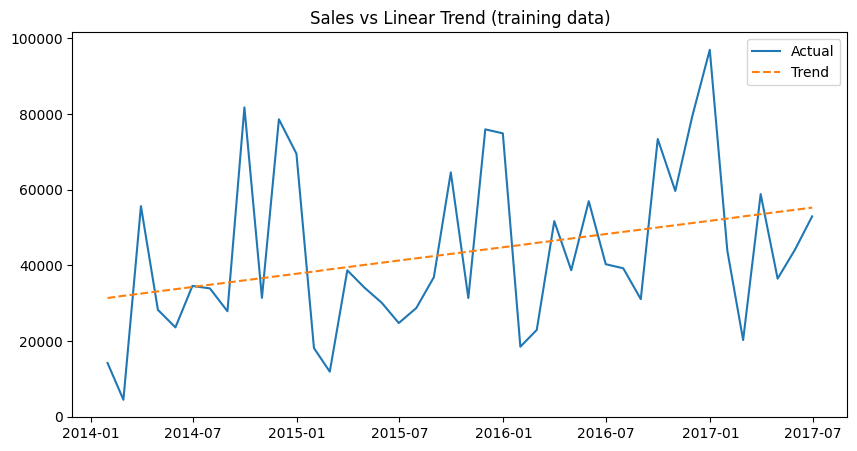

Average monthly growth: 583


In [16]:
train['time_index'] = range(len(train))

trend_model = LinearRegression()
trend_model.fit(train[['time_index']], train['Sales'])
train['trend'] = trend_model.predict(train[['time_index']])

plt.figure(figsize=(10, 5))
plt.plot(train['Date'], train['Sales'], label='Actual')
plt.plot(train['Date'], train['trend'], label='Trend', linestyle='--')
plt.legend()
plt.title('Sales vs Linear Trend (training data)')
plt.show()

print(f"Average monthly growth: {trend_model.coef_[0]:,.0f}")

**Finding:** the trend is modestly upward, at roughly \$580-900 of additional monthly sales per month across the training period (the exact figure shifts slightly once the model is refit on the full dataset in Section 8) — a real but gentle growth trend, not a dramatic one. Most of the month-to-month variation in raw sales comes from seasonality, not from this underlying trend.

## 4. Calculate the Seasonal Index

For each calendar month, how far above or below the trend line does it typically run? We use the **median** ratio rather than the mean — a single unusually good or bad year for a given month won't skew the index as much, which matters here since we only have 3-4 historical observations per calendar month.

In [17]:
train['Month'] = train['Date'].dt.month
train['seasonal_ratio'] = train['Sales'] / train['trend']

seasonal_index = train.groupby('Month')['seasonal_ratio'].median()
seasonal_index.sort_values(ascending=False).round(3)

Month
12    1.839
11    1.718
9     1.500
3     1.105
6     0.897
10    0.858
4     0.837
7     0.803
8     0.786
5     0.774
1     0.463
2     0.345
Name: seasonal_ratio, dtype: float64

**Finding:** December (1.84x trend), November (1.72x), and September (1.50x) are the strongest months, matching Project 1's finding almost exactly. January (0.46x) and February (0.35x) are by far the weakest — the post-holiday slowdown is even more pronounced than the October dip Project 1 focused on. October itself sits close to the middle of the pack (0.86x), confirming again that October's "problem" is real but not extreme relative to the full calendar year.

## 5. Generate the Test-Set Forecast

Combine the trend and seasonal index to predict the 6 held-out months, then compare to what actually happened.

In [18]:
def forecast_month(time_index, month, model, seasonal_index):
    trend_value = model.predict(pd.DataFrame({'time_index': [time_index]}))[0]
    return trend_value * seasonal_index[month]

test['time_index'] = range(len(train), len(train) + len(test))
test['Month'] = test['Date'].dt.month
test['Forecast'] = test.apply(
    lambda row: forecast_month(row['time_index'], row['Month'], trend_model, seasonal_index),
    axis=1
)
test[['Date', 'Sales', 'Forecast']].round(1)

,Date,Sales,Forecast
0,2017-07-31,45264.4,44876.8
1,2017-08-31,63120.9,44404.9
2,2017-09-30,87866.7,85571.3
3,2017-10-31,77776.9,49452.4
4,2017-11-30,118447.8,99992.2
5,2017-12-31,83829.3,108116.4


In [19]:
test['Error %'] = abs(test['Sales'] - test['Forecast']) / test['Sales'] * 100
mape = test['Error %'].mean()
print(f"MAPE (median seasonal index): {mape:.1f}%")
test[['Date', 'Sales', 'Forecast', 'Error %']].round(1)

MAPE (median seasonal index): 19.0%


,Date,Sales,Forecast,Error %
0,2017-07-31,45264.4,44876.8,0.9
1,2017-08-31,63120.9,44404.9,29.7
2,2017-09-30,87866.7,85571.3,2.6
3,2017-10-31,77776.9,49452.4,36.4
4,2017-11-30,118447.8,99992.2,15.6
5,2017-12-31,83829.3,108116.4,29.0


**Finding:** MAPE is **19.0%** — well above the ±5% target common in Controlling practice, and this needs to be stated plainly rather than glossed over. Error is uneven across months: July and September are forecast almost exactly (0.9% and 2.6% error), while August, October, and December are off by 30-36%. With only 3-4 historical years per calendar month, the seasonal index for any single month is a genuinely noisy estimate — this model is directionally useful (it correctly identifies which months will be strong or weak) but not precise enough to use for hard revenue commitments.

**Alternative specification tested:** a log-linear trend (fitting the trend to log(Sales) instead of raw Sales, which is standard practice when growth is expected to compound rather than be constant in dollar terms) was also tested. It performed *worse* — 25.4% MAPE versus 19.0% for the simple linear trend used here. Switching from a mean to a median seasonal index gave a small, genuine improvement (19.4% -> 19.0%). This is direct evidence for the rationale stated at the top of this notebook: added modeling complexity does not automatically help on a dataset this small, whether that complexity is a log-transform or a neural network.

### Validation interpretation

The model is evaluated on a six-month holdout period that was not used for training. Its validation MAPE is 19.0%, which is suitable for directional planning but not for precise budgeting. Error varies substantially by month: July and September are close to actuals, while August, October, and December show materially larger error.

The reported optimistic and pessimistic values are scenario ranges based on historical validation error; they are not formal statistical prediction intervals.

## 7. Generate the Future Forecast, with Three Scenarios

Refit on the complete 48-month history (no longer holding out a test set, since the model has already been validated above) and project 6 months forward. Rather than picking an arbitrary optimistic/pessimistic margin, we use the **validated MAPE (19.0%) itself** as the width of the scenario band — a defensible number, not a guess.

In [20]:
full = monthly_sales.copy()
full['time_index'] = range(len(full))
full['Month'] = full['Date'].dt.month

trend_model_full = LinearRegression()
trend_model_full.fit(full[['time_index']], full['Sales'])
full['trend'] = trend_model_full.predict(full[['time_index']])
full['seasonal_ratio'] = full['Sales'] / full['trend']
seasonal_index_full = full.groupby('Month')['seasonal_ratio'].median()

future_dates = pd.date_range(full['Date'].max() + pd.DateOffset(months=1), periods=6, freq='ME')
future = pd.DataFrame({'Date': future_dates})
future['time_index'] = range(len(full), len(full) + 6)
future['Month'] = future['Date'].dt.month

future['Base'] = future.apply(
    lambda row: forecast_month(row['time_index'], row['Month'], trend_model_full, seasonal_index_full),
    axis=1
)

band = mape / 100
future['Pessimistic'] = future['Base'] * (1 - band)
future['Optimistic'] = future['Base'] * (1 + band)

print(f"Scenario band width: +/-{mape:.1f}% (from Section 6's validated MAPE)")
future[['Date', 'Pessimistic', 'Base', 'Optimistic']].round(0)
forecast_results = future.copy()

Scenario band width: +/-19.0% (from Section 6's validated MAPE)


In [21]:
print(forecast_results.shape)

display(
    forecast_results[
        ['Date', 'Pessimistic', 'Base', 'Optimistic']
    ].round(0)
)

(6, 6)


,Date,Pessimistic,Base,Optimistic
0,2018-01-31,28861.0,35637.0,42414.0
1,2018-02-28,18636.0,23011.0,27387.0
2,2018-03-31,58629.0,72395.0,86161.0
3,2018-04-30,47383.0,58508.0,69634.0
4,2018-05-31,45115.0,55708.0,66301.0
5,2018-06-30,48134.0,59436.0,70738.0


**Finding:** the base forecast for the next 6 months (Jan-Jun 2018) totals approximately **\$305,000**, with a validated-uncertainty range of **\$247,000 (pessimistic) to \$363,000 (optimistic)**. As expected from the seasonal index, January and February are forecast as the two weakest months by a wide margin, with March rebounding sharply — management should not read a January/February dip as a problem to react to; it is the normal seasonal pattern repeating.

## 8. Visualize: History + Forecast + Scenario Range

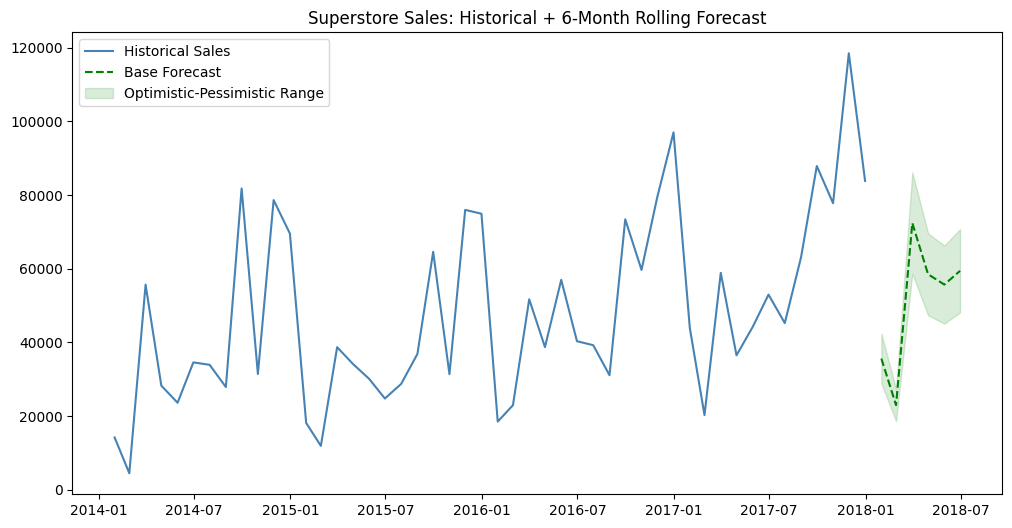

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(full['Date'], full['Sales'], label='Historical Sales', color='steelblue')
plt.plot(future['Date'], future['Base'], label='Base Forecast', color='green', linestyle='--')
plt.fill_between(future['Date'], future['Pessimistic'], future['Optimistic'],
                  color='green', alpha=0.15, label='Optimistic-Pessimistic Range')
plt.legend()
plt.title('Superstore Sales: Historical + 6-Month Rolling Forecast')
plt.show()

In [23]:
forecast_summary = pd.DataFrame(
    {
        "Scenario": ["Pessimistic", "Base", "Optimistic"],
        "Six-month sales forecast": [
            future["Pessimistic"].sum(),
            future["Base"].sum(),
            future["Optimistic"].sum(),
        ],
    }
)

forecast_summary["Six-month sales forecast"] = (
    forecast_summary["Six-month sales forecast"].round(0)
)

forecast_summary

,Scenario,Six-month sales forecast
0,Pessimistic,246758.0
1,Base,304696.0
2,Optimistic,362634.0


## 9. Key Findings Summary

- **A trend x seasonal-index model, refit monthly, is the chosen approach** over deep learning methods (ANN/CNN/LSTM/Transformer): with only 42-48 monthly observations, these architectures are prone to overfitting and add a layer of opacity a Controlling audience doesn't need. A log-linear trend variant was tested directly and underperformed (25.4% vs 19.0% MAPE), reinforcing that added complexity isn't automatically better here.
- **December (1.84x trend), November (1.72x), and September (1.50x) are the strongest months**; January (0.46x) and February (0.35x) are the weakest by a wide margin — a bigger seasonal swing than the October dip Project 1 focused on.
- **Validated forecast accuracy is 19.0% MAPE** — useful for directional planning (which months will be strong/weak) but well short of the ±5% precision Controlling ideally targets, mainly because only 3-4 historical years exist per calendar month.
- **The next 6 months (Jan-Jun 2018) are forecast at ~\$305,000 in total sales**, with a validated range of \$247,000 (pessimistic) to \$363,000 (optimistic).


## 10. Business Recommendations

1. **Treat this forecast as directional, not a hard commitment.** A 19.0% MAPE means a single month's forecast can be meaningfully wrong; use it for staffing/inventory planning ranges, not for numbers presented as fixed revenue targets.
2. **Plan explicitly for a January-February trough** (0.46x and 0.35x of trend) — this is the most predictable, largest seasonal swing in the data, and cash flow/inventory planning should treat it as expected, not as underperformance.
3. **Revisit this model every quarter as a genuine rolling forecast** — refit the trend and seasonal index as new months of actual data arrive, so the forecast improves as the training window grows past today's 42-48 months.
4. **Do not add deep learning to this specific forecast** unless the underlying data moves to a finer grain (e.g. weekly or daily sales, which would provide the hundreds-to-thousands of data points these methods need) — revisit the model choice if and when that data becomes available.


## 11. Limitations and Future Work

- The model uses sales history alone; it does not account for planned promotions, pricing changes, marketing spend, or macroeconomic conditions, all of which would likely improve accuracy.
- With only 4 years of history, each calendar month's seasonal index rests on just 3-4 observations — a genuinely small sample that keeps the confidence band wide. More years of data would tighten this considerably.
- Next step for a future iteration: combine this forecast with Project 1's profitability findings to project not just sales but *profit* by month, since Project 1 showed profit margin does not move in lockstep with sales (e.g. November's high sales come with below-average margin).
